<a href="https://colab.research.google.com/github/Nithya-collab/Qiskit-Quantum-/blob/main/Shortest%20Path%20Optimization%20on%20a%20Small%20Grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shortest Path Optimization on a Small Grid

In [3]:
!pip install qiskit qiskit-aer qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.4 MB/s eta 0:00:00


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit

In [5]:
!mkdir rover_project
!mkdir rover_project/data
!mkdir rover_project/results
!mkdir rover_project/algorithms

In [ ]:
!ls rover_project

algorithms  data  results


In [6]:
import json

data = {"path_length": 6}

with open("rover_project/results/result.json", "w") as f:
    json.dump(data, f)

In [7]:
import qiskit
print(qiskit.__version__)

2.3.1


In [8]:
import numpy as np
import matplotlib.pyplot as plt

0	-> empty space,
1	-> obstacle,
2	-> start,
3	-> goal,  ....✈

In [9]:
grid = np.array([
    [2,0,0,0],
    [0,1,0,0],
    [0,0,1,0],
    [0,0,0,3]
])

print(grid)

[[2 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 3]]


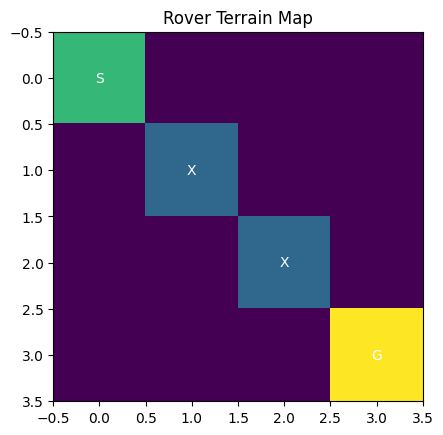

In [10]:
plt.imshow(grid, cmap="viridis")

for i in range(4):
    for j in range(4):
        value = grid[i][j]
        if value == 2:
            plt.text(j, i, "S", ha='center', va='center', color='white')
        elif value == 3:
            plt.text(j, i, "G", ha='center', va='center', color='white')
        elif value == 1:
            plt.text(j, i, "X", ha='center', va='center', color='white')

plt.title("Rover Terrain Map")
plt.show()

In [11]:
start = tuple(np.argwhere(grid == 2)[0])
goal = tuple(np.argwhere(grid == 3)[0])

print("Start:", start)
print("Goal:", goal)

Start: (np.int64(0), np.int64(0))
Goal: (np.int64(3), np.int64(3))


  A* Algorithm Implemenation "*"

In [12]:
moves = [(-1,0),(1,0),(0,-1),(0,1)]

In [13]:
start = tuple(np.argwhere(grid == 2)[0])
goal = tuple(np.argwhere(grid == 3)[0])

print("Start:", start)
print("Goal:", goal)

Start: (np.int64(0), np.int64(0))
Goal: (np.int64(3), np.int64(3))


In [14]:
def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

In [15]:
import heapq

def astar(grid, start, goal):

    rows, cols = grid.shape
    open_list = []
    heapq.heappush(open_list,(0,start))

    came_from = {}
    cost_so_far = {start:0}

    while open_list:

        current = heapq.heappop(open_list)[1]

        if current == goal:
            break

        for move in moves:

            next_node = (current[0]+move[0], current[1]+move[1])

            if 0 <= next_node[0] < rows and 0 <= next_node[1] < cols:

                if grid[next_node] == 1:
                    continue

                new_cost = cost_so_far[current] + 1

                if next_node not in cost_so_far or new_cost < cost_so_far[next_node]:

                    cost_so_far[next_node] = new_cost
                    priority = new_cost + heuristic(goal,next_node)

                    heapq.heappush(open_list,(priority,next_node))
                    came_from[next_node] = current

    path = []
    node = goal

    while node != start:
        path.append(node)
        node = came_from[node]

    path.append(start)
    path.reverse()

    return path

In [16]:
path = astar(grid,start,goal)

print("Path:", path)
print("Path length:", len(path))

Path: [(np.int64(0), np.int64(0)), (np.int64(0), np.int64(1)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(3)), (np.int64(1), np.int64(3)), (np.int64(2), np.int64(3)), (np.int64(3), np.int64(3))]
Path length: 7


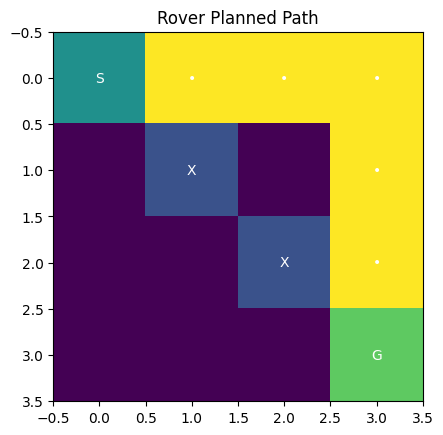

In [17]:
for (x,y) in path:
    if grid[x][y] == 0:
        grid[x][y] = 4

plt.imshow(grid)

for i in range(4):
    for j in range(4):
        if grid[i][j] == 2:
            plt.text(j,i,"S",ha='center',va='center',color='white')
        elif grid[i][j] == 3:
            plt.text(j,i,"G",ha='center',va='center',color='white')
        elif grid[i][j] == 1:
            plt.text(j,i,"X",ha='center',va='center',color='white')
        elif grid[i][j] == 4:
            plt.text(j,i,"•",ha='center',va='center',color='white')

plt.title("Rover Planned Path")
plt.show()

**Execution Time Measurement of A star**

In [18]:
import time

start_time = time.time()

path = astar(grid,start,goal)

end_time = time.time()

astar_time = end_time - start_time
astar_length = len(path)

print("A* Path:", path)
print("Path length:", astar_length)
print("Execution time:", astar_time)

A* Path: [(np.int64(0), np.int64(0)), (np.int64(0), np.int64(1)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(3)), (np.int64(1), np.int64(3)), (np.int64(2), np.int64(3)), (np.int64(3), np.int64(3))]
Path length: 7
Execution time: 0.00016450881958007812


In [19]:
# storing result of execution time

results = {
    "A*": {
        "path_length": astar_length,
        "time": astar_time
    }
}

print(results)

{'A*': {'path_length': 7, 'time': 0.00016450881958007812}}


In [20]:
import pandas as pd

data = {
    "Method": ["A*","QAOA (placeholder)"],
    "Path Length": [astar_length, None],
    "Execution Time": [astar_time, None]
}

df = pd.DataFrame(data)

print(df)

               Method  Path Length  Execution Time
0                  A*          7.0        0.000165
1  QAOA (placeholder)          NaN             NaN


Quantum Optimization test (QAOA)

In [21]:
from qiskit_aer import Aer
from qiskit.quantum_info import Pauli
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler

In [23]:
sampler = StatevectorSampler()

In [24]:
optimizer = COBYLA(maxiter=50)

qaoa = QAOA(
    sampler=sampler,
    optimizer=optimizer,
    reps=1
)

**Small Graph shortest path example**

In [26]:
from qiskit.quantum_info import SparsePauliOp

# Example: 2 edges
cost_operator = SparsePauliOp.from_list([
    ("ZI", 1.0),   # edge 1 weight
    ("IZ", 1.0),   # edge 2 weight
    ("ZZ", 2.0)    # constraint penalty
])

In [27]:
result = qaoa.compute_minimum_eigenvalue(cost_operator)

print("Energy:", result.eigenvalue)
print("Solution:", result.eigenstate)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Energy: -1.6015625
Solution: {'01': 0.3818359375, '11': 0.2080078125, '10': 0.408203125, '00': 0.001953125}
